# Make basic measurements

Make the measurements that are already possible to make with Prez's code. These are:  
* Minimum time taken for the mice to arrive the reward location in a trial. 
    It's only at animal spent > set amount of time, we would say the animal "arrived at the reward". That set amount of time was set to 2s in Prez's code
* Frequency of crossing the reward zone within a trial
* Fraction of time animal stayed at the reward location within a trial

## Helper functions

In [2]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['Hp'] = '#63D15Aff'
    genotype_color['ArchT'] = '#FF9BD6ff'
    genotype_color['eYFP_ArchT'] = '#5ba0d8ff'
    genotype_color['WT'] = 'grey'
    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]

# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
"#7b62c5ff"
'#1F2A63'
'#C276A5'

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [3]:
from util import config
print(config.trial_info_path)
print(config.animal_info_path)

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/trial_info_20260120.csv
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/animal_info_20251220.csv


## Main

### Visualize the cheeseboard maze task variables

In [4]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[45])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [5]:
dl.id, dl.ses_dir

('A', 'ses-07_date-20241211')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

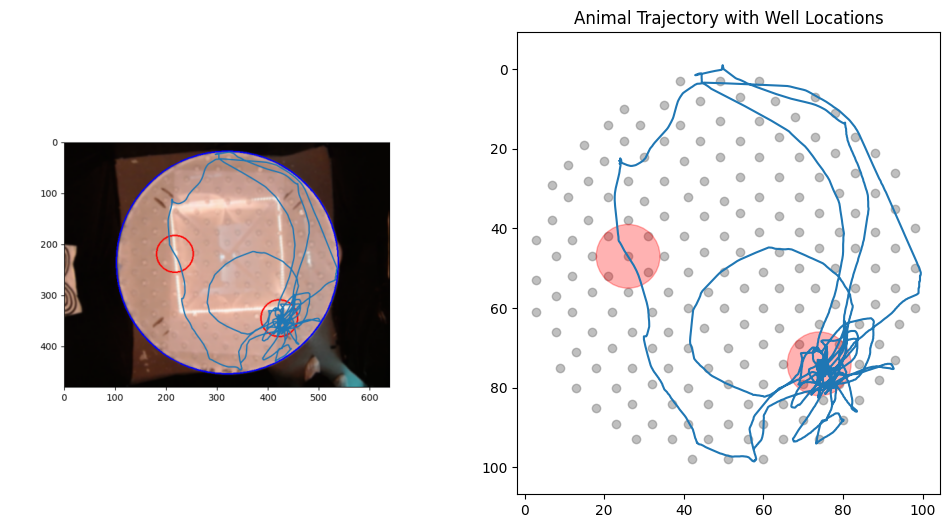

In [6]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [7]:
triggerLoc

,well_row,well_col,x,y
0,J,3,26,47
1,Q,8,74,74


In [8]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,160470,161746,1276,1
1,2017,7183,5166,2
2,8962,14420,5458,2
3,18488,23541,5053,2
4,23672,25425,1753,2
5,28682,31495,2813,2
6,33670,60280,26610,2
7,63489,80872,17383,2
8,82751,86006,3255,2
9,87337,89477,2140,2


### Compute the time animal took to reach the trigger zone

In [9]:
metadata


,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5141,63,BR,20251223,8,5,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5142,63,BR,20251223,8,6,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5143,63,BR,20251223,8,7,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5144,63,BR,20251223,8,8,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN


In [10]:
import numpy as np
import pandas as pd
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# Existing metric
metadata['dist_to_trigger'] = np.nan

# New metrics (all based on the *zone actually entered first*
# or, if never entered, the nearest zone to the start)
metadata['first_choice_trigger'] = np.nan   # which trigger (1/2/3…)
metadata['L_actual']             = np.nan   # actual path length used for analysis
metadata['L_shortest']           = np.nan   # straight-line to edge of that zone
metadata['CIPL']                 = np.nan   # L_actual − L_shortest
metadata['path_eff']             = np.nan   # L_shortest / L_actual * 100

R_TRIGGER = (10/1.2)

# --- SETTINGS you can comment/uncomment ---
REQUIRE_STAY_2S = False          # False → any entry; True → require ≥2 s stay
MIN_DUR_MS      = 2000           # min duration threshold in ms
# -----------------------------------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # ---- Load position ----
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # ---- Load trigger locations ----
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    # ---- Add cumulative distance ----
    pos = add_distance_travelled(position)
    if pos is None or len(pos) == 0:
        metadata.at[trial_id, 'dist_to_trigger'] = np.nan
        continue

    # ---- Add distance-to-trigger columns ----
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i+1)
        if df_trig is None or len(df_trig) == 0:
            continue
        df_trig['trigger_id'] = i + 1
        dfs.append(df_trig)

    # ------------------------------------------------------------
    # CASE 1: never entered ANY reward zone
    # → L_actual = full-trial distance
    # → choose zone closest to start for L_shortest etc.
    # ------------------------------------------------------------
    if len(dfs) == 0:
        # actual path length = full trial
        full_dist = float(pos_['cum_dist'].iloc[-1])

        # starting position
        x0 = float(pos_['x'].iloc[0])
        y0 = float(pos_['y'].iloc[0])

        # distance from start to each zone center
        centers = np.array([
            [float(triggerLoc.iloc[i]['x']), float(triggerLoc.iloc[i]['y'])]
            for i in range(trigger_num)
        ])
        dx = centers[:, 0] - x0
        dy = centers[:, 1] - y0
        d_center = np.sqrt(dx * dx + dy * dy)

        # pick closest zone
        nearest_idx = int(np.argmin(d_center))   # 0-based
        trig_first  = nearest_idx + 1            # 1-based trigger_id

        d_min_center = float(d_center[nearest_idx])
        # shortest distance to edge of that trigger
        L_shortest = max(d_min_center - R_TRIGGER, 0.0)

        # CIPL and path efficiency
        CIPL = full_dist - L_shortest
        path_eff = (L_shortest / full_dist) * 100.0 if full_dist > 0 else np.nan

        # store
        metadata.at[trial_id, 'dist_to_trigger']     = full_dist
        metadata.at[trial_id, 'first_choice_trigger'] = trig_first
        metadata.at[trial_id, 'L_actual']           = full_dist
        metadata.at[trial_id, 'L_shortest']         = L_shortest
        metadata.at[trial_id, 'CIPL']               = CIPL
        metadata.at[trial_id, 'path_eff']           = path_eff

        continue  # go to next trial

    # ------------------------------------------------------------
    # CASE 2: at least one entry to a reward zone
    # ------------------------------------------------------------
    df_all = (
        pd.concat(dfs, ignore_index=True)
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    # OPTIONAL: require ≥ MIN_DUR_MS stays
    if REQUIRE_STAY_2S:
        df_use = df_all[df_all['duration'] >= MIN_DUR_MS].copy()

        # If no such stays, treat like "never reached" but still
        # choose closest reward zone from start.
        if len(df_use) == 0:
            full_dist = float(pos_['cum_dist'].iloc[-1])

            x0 = float(pos_['x'].iloc[0])
            y0 = float(pos_['y'].iloc[0])

            centers = np.array([
                [float(triggerLoc.iloc[i]['x']), float(triggerLoc.iloc[i]['y'])]
                for i in range(trigger_num)
            ])
            dx = centers[:, 0] - x0
            dy = centers[:, 1] - y0
            d_center = np.sqrt(dx * dx + dy * dy)

            nearest_idx = int(np.argmin(d_center))
            trig_first  = nearest_idx + 1
            d_min_center = float(d_center[nearest_idx])

            L_shortest = max(d_min_center - R_TRIGGER, 0.0)
            CIPL = full_dist - L_shortest
            path_eff = (L_shortest / full_dist) * 100.0 if full_dist > 0 else np.nan

            metadata.at[trial_id, 'dist_to_trigger']     = full_dist
            metadata.at[trial_id, 'first_choice_trigger'] = trig_first
            metadata.at[trial_id, 'L_actual']           = full_dist
            metadata.at[trial_id, 'L_shortest']         = L_shortest
            metadata.at[trial_id, 'CIPL']               = CIPL
            metadata.at[trial_id, 'path_eff']           = path_eff
            continue
    else:
        df_use = df_all

    # ------------------------------------------------------------
    # First *chosen* reward zone: earliest qualifying entry
    # ------------------------------------------------------------
    first_entry   = df_use.iloc[0]
    t_enter_first = first_entry['t_enter']
    trig_first    = int(first_entry['trigger_id'])

    # L_actual: distance travelled up to that time
    idxs = np.where(pos_['t'].values <= t_enter_first)[0]
    if len(idxs) == 0:
        L_actual = 0.0
    else:
        L_actual = float(pos_['cum_dist'].iloc[idxs[-1]])

    # ------------------------------------------------------------
    # L_shortest: straight-line from start → edge of *that* trigger
    # ------------------------------------------------------------
    x0 = float(pos_['x'].iloc[0])
    y0 = float(pos_['y'].iloc[0])

    cx = float(triggerLoc.iloc[trig_first - 1]['x'])
    cy = float(triggerLoc.iloc[trig_first - 1]['y'])

    dx = cx - x0
    dy = cy - y0
    d_center = np.sqrt(dx * dx + dy * dy)

    L_shortest = max(d_center - R_TRIGGER, 0.0)

    # ------------------------------------------------------------
    # CIPL + path efficiency
    # ------------------------------------------------------------
    CIPL = L_actual - L_shortest if np.isfinite(L_actual) and np.isfinite(L_shortest) else np.nan
    if L_actual > 0:
        path_eff = (L_shortest / L_actual) * 100.0
    else:
        path_eff = np.nan

    # ------------------------------------------------------------
    # Store everything
    # ------------------------------------------------------------
    metadata.at[trial_id, 'dist_to_trigger']      = L_actual
    metadata.at[trial_id, 'first_choice_trigger'] = trig_first
    metadata.at[trial_id, 'L_actual']             = L_actual
    metadata.at[trial_id, 'L_shortest']           = L_shortest
    metadata.at[trial_id, 'CIPL']                 = CIPL
    metadata.at[trial_id, 'path_eff']             = path_eff

# quick check
metadata[['sub','ses','trial_type','trial_type_day',
          'dist_to_trigger',
          'first_choice_trigger',
          'L_actual',
          'L_shortest',
          'CIPL',
          'path_eff']].head()

 15%|█▌        | 704/4609 [00:07<00:37, 105.44it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1181/4609 [00:12<00:31, 108.03it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2618/4609 [00:24<00:12, 156.31it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:40<00:00, 113.38it/s]


,sub,ses,trial_type,trial_type_day,dist_to_trigger,first_choice_trigger,L_actual,L_shortest,CIPL,path_eff
0,1,1,H,1,21.004940,5.0,21.004940,2.704986,18.299953,12.877858
1,1,1,H,1,121.123247,3.0,121.123247,63.736658,57.386590,52.621325
2,1,1,H,1,39.502281,5.0,39.502281,16.258456,23.243826,41.158271
3,1,1,H,1,7.878806,5.0,7.878806,5.881602,1.997203,74.650938
4,1,1,H,1,132.454986,4.0,132.454986,45.804395,86.650591,34.581103



=== dist_to_trigger ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


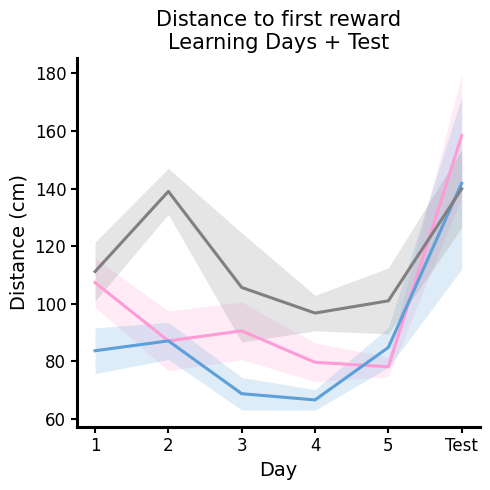


=== CIPL ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


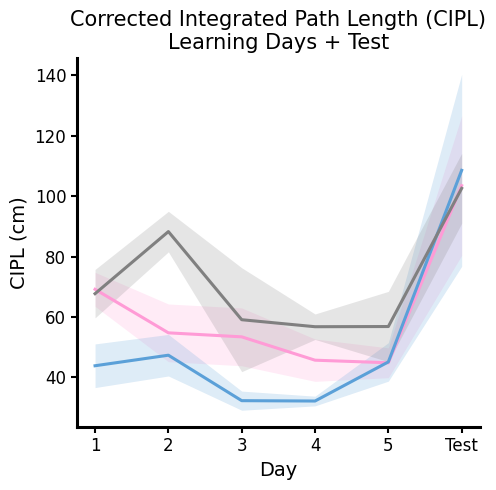


=== path_eff ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


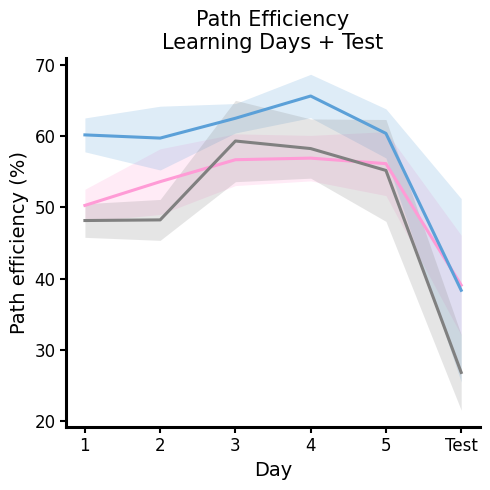

In [11]:
# Distance / CIPL / Path efficiency
# Plot ArchT vs eYFP_ArchT (+/- WT)
# Metrics: dist_to_trigger, CIPL, path_eff

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# OPTIONS for plotting
# ---------------------------------------------------------------------
INCLUDE_WT    = True    # True → include WT, False → only ArchT & eYFP_ArchT
ADD_STAY_TAG  = False   # True → add "(≥2 s stay)" into all titles

# ---------------------------------------------------------------------
# 1. Base filter: usable, not short, genotypes of interest, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST after last L session → day 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # L1–L5 + Test(6)

# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix for an arbitrary metric
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    """
    meta_group: subset of meta_LT for one genotype
    value_col:  name of column to average (e.g. 'dist_to_trigger', 'CIPL', 'path_eff')
    """
    perf_mat = []
    subjects = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete days 1–6 for that metric for this animal
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# ---------------------------------------------------------------------
# 3. Plot helper (ArchT vs eYFP_ArchT (+/- WT))
# ---------------------------------------------------------------------
def plot_metric_for_all_genotypes(meta_LT, value_col, ylabel, title,
                                  include_wt=True):  # NEW ARG
    """
    include_wt = False → only plot ArchT & eYFP_ArchT
    """
    # split by genotype
    meta_ArchT = meta_LT[meta_LT['genotype'] == 'ArchT']
    meta_eYFP  = meta_LT[meta_LT['genotype'] == 'eYFP_ArchT']
    meta_WT    = meta_LT[meta_LT['genotype'] == 'WT']

    mat_ArchT, subs_ArchT = build_genotype_matrix(meta_ArchT, value_col)
    mat_eYFP,  subs_eYFP  = build_genotype_matrix(meta_eYFP,  value_col)
    mat_WT,    subs_WT    = build_genotype_matrix(meta_WT,    value_col)

    print(f"\n=== {value_col} ===")
    print("ArchT animals plotted:", len(subs_ArchT))
    print("eYFP_ArchT animals plotted:", len(subs_eYFP))
    print("WT animals plotted:", len(subs_WT))

    plt.figure(figsize=(5,5))
    x_vals = plot_days - 1

    def plot_group(mat, subs, gkey, glabel):
        if mat is None or mat.size == 0:
            return
        col = get_genotype_color(gkey)   # no WT fallback requested

        mean_ = np.nanmean(mat, axis=0)
        sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

        # shaded SEM
        plt.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.20,
            linewidth=0
        )

        # mean curve
        plt.plot(
            x_vals, mean_,
            color=col,
            linewidth=2.2,
            label=f'{glabel} (n={len(subs)})'
        )

    # always plot ArchT + eYFP_ArchT
    plot_group(mat_ArchT, subs_ArchT, 'ArchT',      'ArchT')
    plot_group(mat_eYFP,  subs_eYFP,  'eYFP_ArchT', 'eYFP_ArchT')

    # optionally plot WT
    if include_wt:
        plot_group(mat_WT, subs_WT, 'WT', 'WT')

    # axes, style
    plt.xlabel('Day', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=15)

    plt.xticks(np.arange(6), ['1','2','3','4','5','Test'], fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)

#    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4. Call for each metric
# ---------------------------------------------------------------------
stay_tag = " (≥2 s stay)" if ADD_STAY_TAG else ""

# a) Distance (stored as dist_to_trigger)
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='dist_to_trigger',
    ylabel='Distance (cm)',
    title=f'Distance to first reward{stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

# b) CIPL = L_actual - L_shortest
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='CIPL',
    ylabel='CIPL (cm)',
    title=f'Corrected Integrated Path Length (CIPL){stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

# c) Path efficiency = L_shortest / L_actual * 100
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='path_eff',
    ylabel='Path efficiency (%)',
    title=f'Path Efficiency{stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

Test day CIPL per animal:
  ArchT:      n = 6,  animals = [28 29 30 31 32 33]
  eYFP_ArchT: n = 6,   animals = [34 35 36 37 38 39]
  WT:         n = 4,     animals = [24 25 26 27]
ArchT vs eYFP_ArchT: raw p = 0.937
ArchT vs WT: raw p = 0.762
eYFP_ArchT vs WT: raw p = 0.914

FDR-corrected p-values (BH):
  ArchT vs eYFP_ArchT: p_FDR = 0.937
  ArchT vs WT: p_FDR = 0.937
  eYFP_ArchT vs WT: p_FDR = 0.937


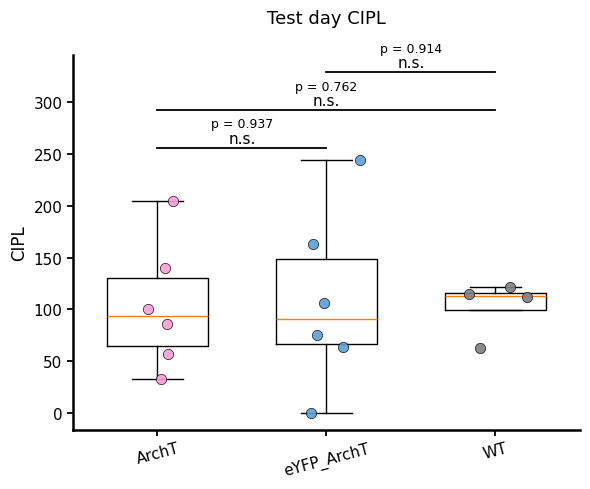

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Try FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR skipped (raw p-values used).")

# ============================================================
# OPTIONS (ArchT / eYFP_ArchT / optional WT)
# ============================================================
INCLUDE_WT   = True    # True → include WT, False → only ArchT & eYFP_ArchT
ADD_2S_TAG   = False   # True → add "(≥2 s stay)" in title

# Which metric to compare (boxplot on TEST day per animal)
METRIC_COL   = 'CIPL'  # or 'dist_to_trigger' or 'path_eff'

# ============================================================
# 1) Build meta_LT with plot_day (L1–5, Test=6)
# ============================================================
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[METRIC_COL].notna())
].copy()

meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# Keep only test day
meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()


# ============================================================
# 2) Helper: extract per-animal values on test day
# ============================================================
def get_group_vals(meta_df, genotype, value_col):
    m = meta_df[meta_df['genotype'] == genotype]
    if m.empty:
        return np.array([]), np.array([])
    per_sub = (
        m.groupby('sub')[value_col]
         .mean()
         .astype(float)
    )
    return per_sub.values, per_sub.index.values  # vals, animal IDs


# Base two groups
vals_ArchT, subs_ArchT = get_group_vals(meta_test, 'ArchT',       METRIC_COL)
vals_eYFP,  subs_eYFP  = get_group_vals(meta_test, 'eYFP_ArchT',  METRIC_COL)

print(f"Test day {METRIC_COL} per animal:")
print(f"  ArchT:      n = {len(vals_ArchT)},  animals = {subs_ArchT}")
print(f"  eYFP_ArchT: n = {len(vals_eYFP)},   animals = {subs_eYFP}")

# Optional WT
if INCLUDE_WT:
    vals_WT, subs_WT = get_group_vals(meta_test, 'WT', METRIC_COL)
    print(f"  WT:         n = {len(vals_WT)},     animals = {subs_WT}")


# ============================================================
# 3) Assemble data & group labels depending on options
# ============================================================
if INCLUDE_WT:
    data   = [vals_ArchT, vals_eYFP, vals_WT]
    groups = ["ArchT", "eYFP_ArchT", "WT"]
else:
    data   = [vals_ArchT, vals_eYFP]
    groups = ["ArchT", "eYFP_ArchT"]

positions = np.arange(len(groups))


# ============================================================
# 4) Boxplot + jitter
# ============================================================
def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

fig, ax = plt.subplots(figsize=(6, 5))

# plain boxes (no fliers)
ax.boxplot(
    data,
    positions=positions,
    widths=0.6,
    patch_artist=False,
    showfliers=False
)

# jittered points
for i, vals in enumerate(data):
    if len(vals) == 0:
        continue
    x = np.random.normal(positions[i], 0.14, size=len(vals))
    col = get_genotype_color(groups[i])   # expects 'ArchT', 'eYFP_ArchT', 'WT'
    ax.scatter(
        x, vals,
        s=55,
        color=col,
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )


# ============================================================
# 5) Mann–Whitney + FDR (BH) – FDR printed, RAW p on figure
# ============================================================
comparisons = []
comparisons.append(("ArchT vs eYFP_ArchT", 0, 1, vals_ArchT, vals_eYFP))

if INCLUDE_WT:
    comparisons.append(("ArchT vs WT",        0, 2, vals_ArchT, vals_WT))
    comparisons.append(("eYFP_ArchT vs WT",   1, 2, vals_eYFP,  vals_WT))

# raw p-values
p_raw = []
for name, _, _, v1, v2 in comparisons:
    p = mwu(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR for reporting only
if HAS_SM:
    mask = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask.any():
        _, p_corr, _, _ = multipletests(p_raw[mask], alpha=0.05, method='fdr_bh')
        p_adj[mask] = p_corr
    print("\nFDR-corrected p-values (BH):")
    for (name, *_), pF in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {pF:.3g}")
else:
    print("\nUsing raw p-values only (no FDR)\n")

# ---- bars / stars / p USING RAW p-values ----
all_vals = np.concatenate([v for v in data if len(v) > 0]) if any(len(v) > 0 for v in data) else np.array([np.nan])
ymax   = np.nanmax(all_vals)
y_base = ymax * 1.05
y_step = 0.15 * ymax

for (name, i, j, _, _), p_r in zip(comparisons, p_raw):
    if np.isnan(p_r) or not np.isfinite(ymax):
        continue

    y = y_base
    y_base += y_step

    # straight horizontal bar (no dips)
    ax.plot(
        [positions[i], positions[j]],
        [y, y],
        color='k',
        lw=1.3
    )

    # stars
    ax.text(
        (positions[i] + positions[j]) / 2,
        y + 0.02 * ymax,
        p_to_stars(p_r),
        ha='center',
        fontsize=11
    )

    # numeric raw p-value
    ax.text(
        (positions[i] + positions[j]) / 2,
        y + 0.08 * ymax,
        f"p = {p_r:.3g}",
        ha='center',
        fontsize=9
    )


# ============================================================
# 6) Cosmetics + title with optional "(≥2 s stay)"
# ============================================================
ax.set_xticks(positions)
ax.set_xticklabels(groups, fontsize=11, rotation=15)
ax.set_ylabel(f'{METRIC_COL}', fontsize=12)

stay_tag = " (≥2 s stay)" if ADD_2S_TAG else ""
ax.set_title(f"Test day {METRIC_COL}{stay_tag}\n", fontsize=13, pad=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', width=1.3, length=4)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

  genotype  total_trial_n   mean_dist     sd_dist   n
0     ChR2              1  158.672058  127.874045  12
1     ChR2              2  280.284556  219.043188  12
2     ChR2              3  145.021766  130.589044  12
3     ChR2              4  198.219964  127.194255  12
4     ChR2              5  236.295929  228.560030  12


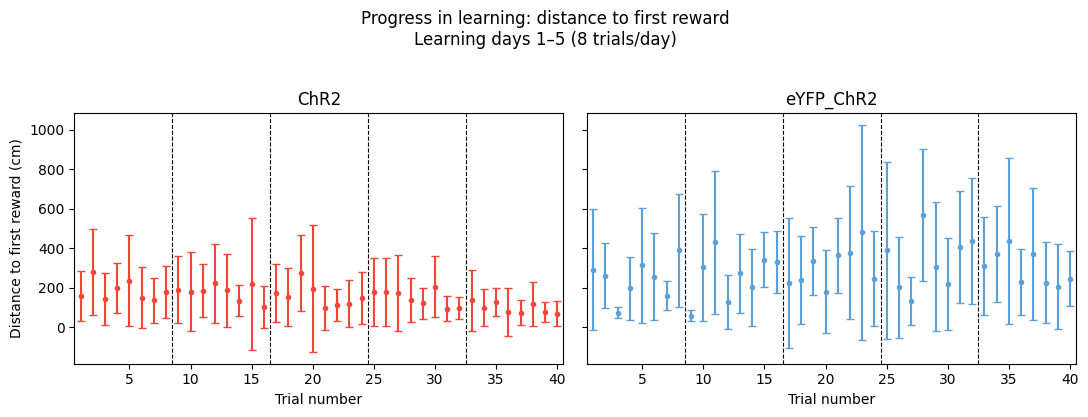

In [ ]:
# progress of learning

# ------------------------------------------------------------
# 1) Filter: usable, not short, ChR2/eYFP, LEARNING (L) days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].between(1, 5)) &
    (metadata['dist_to_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Ensure we have trial_in_day = 1..8
# ------------------------------------------------------------
trials_per_day = 8

candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    # fall back: order within session for each animal
    meta_L = meta_L.sort_values(['sub', 'ses', 'trial_type_day']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, trials_per_day)].copy()

# ------------------------------------------------------------
# 3) Create global trial index = "total_trial_n" (1..40 for 5 days)
# ------------------------------------------------------------
meta_L['total_trial_n'] = (
    (meta_L['trial_type_day'] - 1) * trials_per_day + meta_L['trial_in_day']
).astype(int)

# ------------------------------------------------------------
# 4) Group: mean & SD distance per genotype × total_trial_n
# ------------------------------------------------------------
summary = (
    meta_L
    .groupby(['genotype', 'total_trial_n'])['dist_to_trigger']
    .agg(mean_dist='mean', sd_dist='std', n='size')
    .reset_index()
)

print(summary.head())

# ------------------------------------------------------------
# 5) Plot: error bars (mean ± SD) per trial, faceted by group
# ------------------------------------------------------------
groups = ['ChR2', 'eYFP_ChR2']
colors = {g: get_genotype_color(g) for g in groups}

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, g in zip(axes, groups):
    df_g = summary[summary['genotype'] == g].sort_values('total_trial_n')

    x = df_g['total_trial_n'].values
    y = df_g['mean_dist'].values
    sd = df_g['sd_dist'].values

    # vertical error bars only (like your R code)
    ax.errorbar(
        x, y,
        yerr=sd,
        fmt='none',
        ecolor=colors[g],
        elinewidth=1.5,
        capsize=3
    )

    # optional: mean points
    ax.plot(x, y, marker='o', linestyle='none', color=colors[g], markersize=3)

    # vertical dashed lines between learning days (every 8 trials)
    for boundary in range(trials_per_day, trials_per_day * 5, trials_per_day):
        ax.axvline(boundary + 0.5, color='k', linestyle='--', linewidth=0.8)

    ax.set_title(g)
    ax.set_xlabel('Trial number')
    ax.set_xlim(0.5, trials_per_day * 5 + 0.5)

axes[0].set_ylabel('Distance to first reward (cm)')

plt.suptitle('Progress in learning: distance to first reward\nLearning days 1–5 (8 trials/day)', y=1.03, fontsize=12)

plt.tight_layout()
plt.show()


=== dist_to_trigger ===
ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
ChR2_short animals plotted: 4


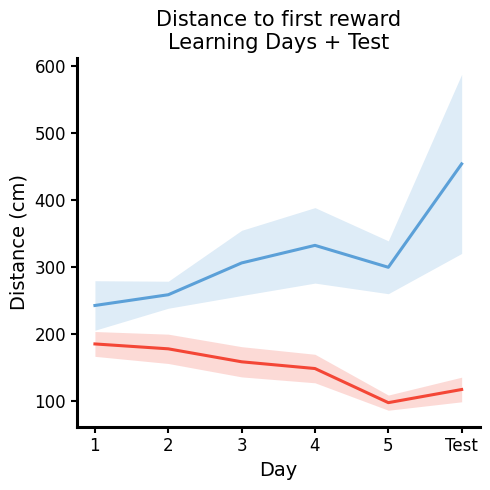


=== CIPL ===
ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
ChR2_short animals plotted: 4


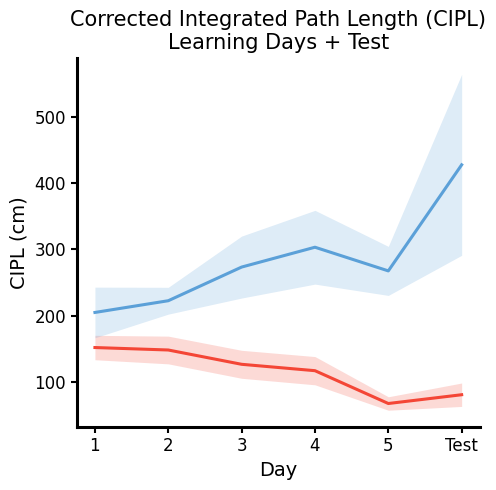


=== path_eff ===
ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
ChR2_short animals plotted: 4


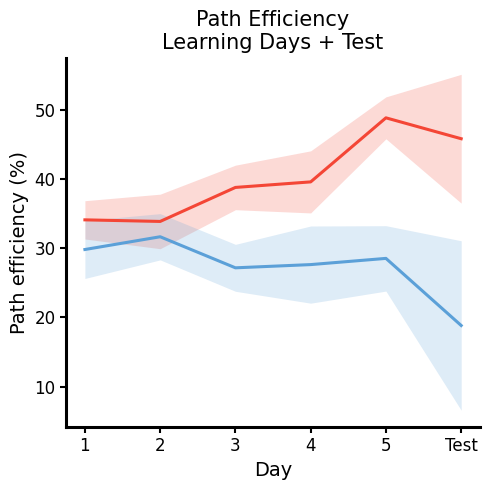

In [61]:
# Distance / CIPL / Path efficiency
# Plot ChR2 vs eYFP_ChR2 vs Hp or ChR2_short
# Metrics: dist_to_trigger, CIPL, path_eff

# ---------------------------------------------------------------------
# OPTIONS for plotting
# ---------------------------------------------------------------------
INCLUDE_THIRD  = False   # True → plot third group, False → only ChR2 & eYFP_ChR2
USE_SHORT      = True   # True → use ChR2_short, False → use Hp
ADD_STAY_TAG   = False   #  True → add "(≥2 s stay)" into all titles

# ---------------------------------------------------------------------
# 1. Base filter: usable, not short, genotypes of interest, L or T
#    (we include BOTH Hp and ChR2_short here, and decide later which to plot)
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp', 'ChR2_short'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST after last L session → day 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # L1–L5 + Test(6)

# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix for an arbitrary metric
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    """
    meta_group: subset of meta_LT for one genotype
    value_col:  name of column to average (e.g. 'dist_to_trigger', 'CIPL', 'path_eff')
    """
    perf_mat = []
    subjects = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete days 1–6 for that metric for this animal
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# ---------------------------------------------------------------------
# 3. Plot helper with switch for Hp vs ChR2_short
# ---------------------------------------------------------------------
def plot_metric_for_all_genotypes(meta_LT, value_col, ylabel, title,
                                  use_short_instead_of_hp=False,
                                  include_third_group=True):  # NEW ARG
    """
    use_short_instead_of_hp = False  → third group is 'Hp'
    use_short_instead_of_hp = True   → third group is 'ChR2_short'
    include_third_group     = False  → only plot ChR2 & eYFP_ChR2
    """
    # split by genotype
    meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
    meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

    if use_short_instead_of_hp:
        third_key   = 'ChR2_short'
        third_label = 'ChR2_short'
    else:
        third_key   = 'Hp'
        third_label = 'Hp'

    meta_third = meta_LT[meta_LT['genotype'] == third_key]

    mat_ChR2,  subs_ChR2  = build_genotype_matrix(meta_ChR2,  value_col)
    mat_eYFP,  subs_eYFP  = build_genotype_matrix(meta_eYFP,  value_col)
    mat_third, subs_third = build_genotype_matrix(meta_third, value_col)

    print(f"\n=== {value_col} ===")
    print("ChR2 animals plotted:", len(subs_ChR2))
    print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
    print(f"{third_key} animals plotted:", len(subs_third))

    plt.figure(figsize=(5,5))
    x_vals = plot_days - 1

    def plot_group(mat, subs, gkey, glabel):
        if mat is None or mat.size == 0:
            return
        col = get_genotype_color(gkey)   # your existing color helper

        mean_ = np.nanmean(mat, axis=0)
        sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

        # shaded SEM
        plt.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.20,
            linewidth=0
        )

        # mean curve
        plt.plot(
            x_vals, mean_,
            color=col,
            linewidth=2.2,
            label=f'{glabel} (n={len(subs)})'
        )

    # always plot ChR2 + eYFP
    plot_group(mat_ChR2,  subs_ChR2,  'ChR2',      'ChR2')
    plot_group(mat_eYFP,  subs_eYFP,  'eYFP_ChR2', 'eYFP_ChR2')

    # only plot third group if requested
    if include_third_group:
        plot_group(mat_third, subs_third, third_key, third_label)

    # axes, style
    plt.xlabel('Day', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=15)

    plt.xticks(np.arange(6), ['1','2','3','4','5','Test'], fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)

#    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4. Call for each metric
# ---------------------------------------------------------------------

stay_tag = " (≥2 s stay)" if ADD_STAY_TAG else ""

# a) Distance (stored as dist_to_trigger)
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='dist_to_trigger',
    ylabel='Distance (cm)',
    title=f'Distance to first reward{stay_tag}\nLearning Days + Test',
    use_short_instead_of_hp=USE_SHORT,
    include_third_group=INCLUDE_THIRD
)

# b) CIPL = L_actual - L_shortest
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='CIPL',
    ylabel='CIPL (cm)',
    title=f'Corrected Integrated Path Length (CIPL){stay_tag}\nLearning Days + Test',
    use_short_instead_of_hp=USE_SHORT,
    include_third_group=INCLUDE_THIRD
)

# c) Path efficiency = L_shortest / L_actual * 100
plot_metric_for_all_genotypes(
    meta_LT,
    value_col='path_eff',
    ylabel='Path efficiency (%)',
    title=f'Path Efficiency{stay_tag}\nLearning Days + Test',
    use_short_instead_of_hp=USE_SHORT,
    include_third_group=INCLUDE_THIRD
)

Test day CIPL per animal:
  ChR2:       n = 12,  animals = [ 1  3  4  6  7  8  9 10 11 12 16 18]
  eYFP_ChR2:  n = 5,  animals = [19 20 21 22 23]
ChR2 vs eYFP: raw p = 0.0194

FDR-corrected p-values (BH):
  ChR2 vs eYFP: p_FDR = 0.0194


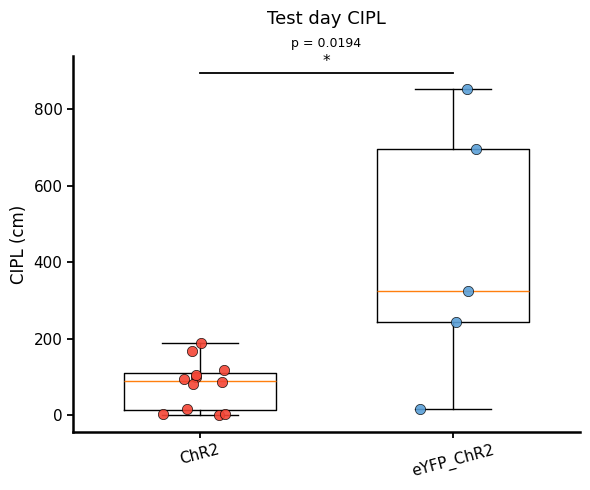

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Try FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR skipped (raw p-values used).")

# ============================================================
# OPTIONS
# ============================================================
# 1) Whether to include a third group at all
INCLUDE_THIRD_GROUP = False   # False → only ChR2 & eYFP_ChR2

# 2) If third group is included, which genotype should it be?
USE_SHORT_THIRD = True       # True → ChR2_short, False → Hp

# 3) Whether to add "(≥2 s stay)" in the title
ADD_2S_TAG = False           # True → add text, False → no text

# Column name for CIPL in your metadata
CIPL_COL = 'CIPL'            # or 'CIPL_first' etc.


# ============================================================
# 1) Build meta_LT with plot_day (L1–5, Test=6)
# ============================================================
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp', 'ChR2_short'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[CIPL_COL].notna())
].copy()

meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# Keep only test day
meta_test = meta_LT[meta_LT['plot_day'] == 6].copy()


# ============================================================
# 2) Helper: extract per-animal CIPL on test day
# ============================================================
def get_group_vals(meta_df, genotype, value_col):
    m = meta_df[meta_df['genotype'] == genotype]
    if m.empty:
        return np.array([]), np.array([])
    per_sub = (
        m.groupby('sub')[value_col]
         .mean()
         .astype(float)
    )
    return per_sub.values, per_sub.index.values  # vals, animal IDs


# Base two groups
vals_ChR2,  subs_ChR2  = get_group_vals(meta_test, 'ChR2',      CIPL_COL)
vals_eYFP,  subs_eYFP  = get_group_vals(meta_test, 'eYFP_ChR2', CIPL_COL)

print("Test day CIPL per animal:")
print(f"  ChR2:       n = {len(vals_ChR2)},  animals = {subs_ChR2}")
print(f"  eYFP_ChR2:  n = {len(vals_eYFP)},  animals = {subs_eYFP}")

# Third group (optional)
if INCLUDE_THIRD_GROUP:
    if USE_SHORT_THIRD:
        third_key   = 'ChR2_short'
        third_label = 'ChR2 short'
    else:
        third_key   = 'Hp'
        third_label = 'Hp'

    vals_third, subs_third = get_group_vals(meta_test, third_key, CIPL_COL)
    print(f"  {third_key}: n = {len(vals_third)}, animals = {subs_third}")


# ============================================================
# 3) Assemble data & group labels depending on options
# ============================================================
if INCLUDE_THIRD_GROUP:
    data      = [vals_ChR2, vals_eYFP, vals_third]
    groups    = ["ChR2", "eYFP_ChR2", third_label]
else:
    data      = [vals_ChR2, vals_eYFP]
    groups    = ["ChR2", "eYFP_ChR2"]

positions = np.arange(len(groups))


# ============================================================
# 4) Boxplot + jitter
# ============================================================
def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

def mwu(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

fig, ax = plt.subplots(figsize=(6, 5))

# plain boxes (no fliers)
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.6,
    patch_artist=False,
    showfliers=False
)

# jittered points
for i, vals in enumerate(data):
    if len(vals) == 0:
        continue
    x = np.random.normal(positions[i], 0.08, size=len(vals))
    # assume your helper has keys: 'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp'
    key_for_color = groups[i].replace(" ", "_")
    col = get_genotype_color(key_for_color)
    ax.scatter(
        x, vals,
        s=55,
        color=col,
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )


# ============================================================
# 5) Mann–Whitney + FDR (BH) – FDR printed, RAW p on figure
# ============================================================
comparisons = []

# always have ChR2 vs eYFP
comparisons.append(("ChR2 vs eYFP", 0, 1, vals_ChR2, vals_eYFP))

if INCLUDE_THIRD_GROUP:
    comparisons.append((f"ChR2 vs {third_label}", 0, 2, vals_ChR2,  vals_third))
    comparisons.append((f"eYFP vs {third_label}", 1, 2, vals_eYFP,  vals_third))

# raw p-values
p_raw = []
for name, _, _, v1, v2 in comparisons:
    p = mwu(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR for reporting only
if HAS_SM:
    mask = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask.any():
        _, p_corr, _, _ = multipletests(p_raw[mask], alpha=0.05, method='fdr_bh')
        p_adj[mask] = p_corr
    print("\nFDR-corrected p-values (BH):")
    for (name, *_), pF in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {pF:.3g}")
else:
    print("\nUsing raw p-values only (no FDR)\n")

# ---- bars / stars / p USING RAW p-values ----
all_vals = np.concatenate([v for v in data if len(v) > 0])
ymax   = np.nanmax(all_vals)
y_base = ymax * 1.05
# if fewer comparisons, step can be smaller; but 0.15*ymax is fine
y_step = 0.15 * ymax

for (name, i, j, _, _), p_r in zip(comparisons, p_raw):
    if np.isnan(p_r):
        continue
    s = p_to_stars(p_r)

    y = y_base
    y_base += y_step

    # straight horizontal bar (no dips)
    ax.plot(
        [positions[i], positions[j]],
        [y, y],
        color='k',
        lw=1.3
    )

    # stars
    ax.text(
        (positions[i] + positions[j]) / 2,
        y + 0.02 * ymax,
        s,
        ha='center',
        fontsize=11
    )

    # numeric raw p-value
    ax.text(
        (positions[i] + positions[j]) / 2,
        y + 0.08 * ymax,
        f"p = {p_r:.3g}",
        ha='center',
        fontsize=9
    )


# ============================================================
# 6) Cosmetics + title with optional "(≥2 s stay)"
# ============================================================
ax.set_xticks(positions)
ax.set_xticklabels(groups, fontsize=11, rotation=15)
ax.set_ylabel('CIPL (cm)', fontsize=12)

if INCLUDE_THIRD_GROUP:
    comp_part = "ChR2 vs eYFP vs " + third_label
else:
    comp_part = "ChR2 vs eYFP"

stay_tag = " (≥2 s stay)" if ADD_2S_TAG else ""
ax.set_title(f"Test day CIPL{stay_tag}\n", fontsize=13, pad=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', width=1.3, length=4)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [17]:

# ============================================================
# Compute mean speed per trial:
#   1) mean_speed          = mean over all timepoints
#   2) mean_speed_moving   = mean after removing "still" samples
# Store both into metadata.
# ============================================================

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

metadata['mean_speed'] = np.nan          # cm/s, includes still time
metadata['mean_speed_moving'] = np.nan   # cm/s, excludes still time

# --- SETTINGS ---
# Define "still" as speed <= STILL_THRESH (cm/s)
STILL_THRESH = 0.0   # keep 0.0 if still samples are exactly 0; set e.g. 0.5 if you want a small threshold
# ----------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    pos = add_speed(position)

    if 'speed' not in pos.columns:
        continue

    speeds = pos['speed'].values.astype(float)

    # finite only
    speeds = speeds[np.isfinite(speeds)]
    if len(speeds) == 0:
        continue

    # 1) mean speed including still time
    metadata.at[trial_id, 'mean_speed'] = float(np.nanmean(speeds))

    # 2) mean speed excluding still time (moving only)
    moving = speeds[speeds > STILL_THRESH]
    if len(moving) > 0:
        metadata.at[trial_id, 'mean_speed_moving'] = float(np.nanmean(moving))
    else:
        metadata.at[trial_id, 'mean_speed_moving'] = np.nan

metadata[['sub','ses','trial_type','trial_type_day','mean_speed','mean_speed_moving']].head()

 16%|█▌        | 725/4609 [00:04<00:24, 157.89it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1198/4609 [00:07<00:20, 164.54it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2619/4609 [00:15<00:06, 286.27it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:24<00:00, 185.46it/s]


,sub,ses,trial_type,trial_type_day,mean_speed,mean_speed_moving
0,1,1,H,1,13.183545,14.252018
1,1,1,H,1,9.790948,10.727092
2,1,1,H,1,9.168459,11.081422
3,1,1,H,1,9.678405,11.026503
4,1,1,H,1,10.652230,11.998895


ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
Hp animals plotted: 7


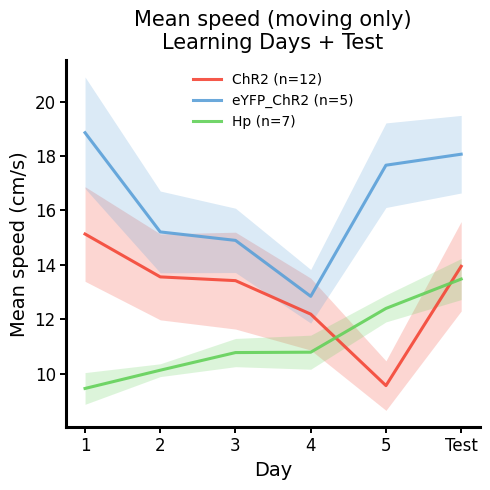

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# OPTION: choose which speed metric to plot
#   'mean_speed'         -> includes still time
#   'mean_speed_moving'  -> excludes still time
# ============================================================
SPEED_COL = 'mean_speed_moving'          # <-- change to 'mean_speed_moving' to plot moving-only

# ---------------------------------------------------------------------
# 1) Filter metadata: usable, not short, three genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[SPEED_COL].notna())
].copy()

# Create plot_day: learning = 1–5, test = 6 (assigned per animal)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix (SPEED_COL), require complete days
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, require_complete=True):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[SPEED_COL].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue
        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2'].copy()
meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp'].copy()

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2, require_complete=True)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP, require_complete=True)
mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp,   require_complete=True)

print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
print("Hp animals plotted:", len(subs_Hp))

# ------------------------------------------------------------
# 3) Plot (mean ± shaded SEM only)
# ------------------------------------------------------------
plt.figure(figsize=(5,5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, color, label, alpha_fill=0.22, alpha_line=0.9):
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=color,
        alpha=alpha_fill,
        linewidth=0
    )

    plt.plot(
        x_vals,
        mean_,
        '-',
        color=color,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

plot_group_shaded(mat_ChR2, subs_ChR2,
                  color=get_genotype_color('ChR2'),
                  label='ChR2')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  color=get_genotype_color('eYFP_ChR2'),
                  label='eYFP_ChR2')

plot_group_shaded(mat_Hp, subs_Hp,
                  color=get_genotype_color('Hp'),
                  label='Hp')

# ------------------------------------------------------------
# axis + style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Mean speed (cm/s)', fontsize=14)

plt.xticks(np.arange(6), ['1','2','3','4','5','Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.legend(frameon=False)

title_metric = "Mean speed" if SPEED_COL == "mean_speed" else "Mean speed (moving only)"
plt.title(f'{title_metric}\nLearning Days + Test', fontsize=15, pad=8)

plt.tight_layout()
plt.show()

[Per-trial paired] n=1280 trials | Wilcoxon p=7.37e-211
  mean(mean_speed)        = 10.933 cm/s
  mean(mean_speed_moving) = 12.748 cm/s
  mean(diff moving-all)   = 1.815 cm/s

[Per-animal paired] n=12 animals | Wilcoxon p=0.000488
  mean(mean_speed)        = 11.524 cm/s
  mean(mean_speed_moving) = 13.291 cm/s
  mean(diff moving-all)   = 1.766 cm/s


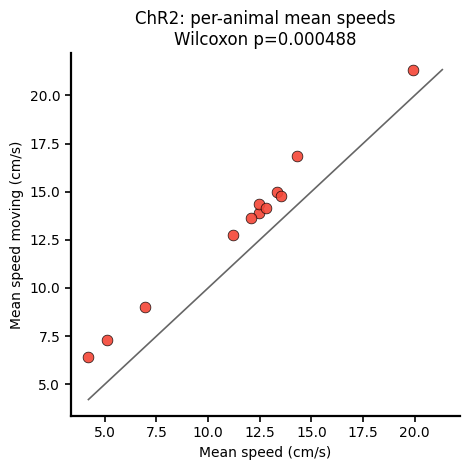

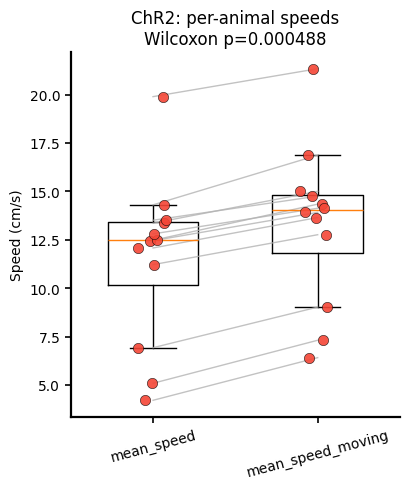

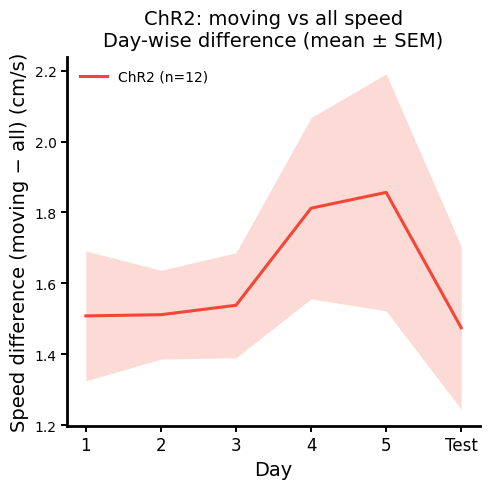

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ============================================================
# Compare mean_speed vs mean_speed_moving for ChR2
#  - does two paired comparisons:
#      (A) per-trial (paired by trial row)
#      (B) per-animal (paired by sub mean across trials)
#  - makes 2 plots:
#      (1) paired scatter (mean_speed vs mean_speed_moving)
#      (2) paired boxplot + connecting lines
#  - PLUS (NEW):
#      (3) day-wise difference across L1–L5 + Test (day 6)
# ============================================================

COL_ALL    = 'mean_speed'
COL_MOVING = 'mean_speed_moving'

# -----------------------------
# 1) Filter ChR2 trials with both metrics present
# -----------------------------
m = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata[COL_ALL].notna()) &
    (metadata[COL_MOVING].notna())
].copy()

# ===== (A) per-trial paired test =====
a_trial = m[COL_ALL].astype(float).values
b_trial = m[COL_MOVING].astype(float).values

stat_t, p_t = wilcoxon(b_trial, a_trial, alternative='two-sided')
print(f"[Per-trial paired] n={len(a_trial)} trials | Wilcoxon p={p_t:.3g}")
print(f"  mean(mean_speed)        = {np.nanmean(a_trial):.3f} cm/s")
print(f"  mean(mean_speed_moving) = {np.nanmean(b_trial):.3f} cm/s")
print(f"  mean(diff moving-all)   = {np.nanmean(b_trial - a_trial):.3f} cm/s")

# ===== (B) per-animal paired test =====
per_sub = (
    m.groupby('sub')[[COL_ALL, COL_MOVING]]
     .mean()
     .dropna()
)

a_sub = per_sub[COL_ALL].astype(float).values
b_sub = per_sub[COL_MOVING].astype(float).values

if len(per_sub) >= 2:
    stat_s, p_s = wilcoxon(b_sub, a_sub, alternative='two-sided')
    print(f"\n[Per-animal paired] n={len(a_sub)} animals | Wilcoxon p={p_s:.3g}")
    print(f"  mean(mean_speed)        = {np.nanmean(a_sub):.3f} cm/s")
    print(f"  mean(mean_speed_moving) = {np.nanmean(b_sub):.3f} cm/s")
    print(f"  mean(diff moving-all)   = {np.nanmean(b_sub - a_sub):.3f} cm/s")
else:
    print("\n[Per-animal paired] Not enough animals with both metrics to run Wilcoxon.")

# -----------------------------
# 2) Plot 1: scatter (per-animal means)
# -----------------------------
fig, ax = plt.subplots(figsize=(4.8, 4.8))

ax.scatter(a_sub, b_sub, s=60, color=get_genotype_color('ChR2'), edgecolor='k', linewidth=0.5, alpha=0.9)

# identity line
lo = np.nanmin(np.concatenate([a_sub, b_sub]))
hi = np.nanmax(np.concatenate([a_sub, b_sub]))
ax.plot([lo, hi], [lo, hi], '-', color='k', lw=1.2, alpha=0.6)

ax.set_xlabel('Mean speed (cm/s)')
ax.set_ylabel('Mean speed moving (cm/s)')
ax.set_title(f'ChR2: per-animal mean speeds\nWilcoxon p={p_s:.3g}' if len(per_sub) >= 2 else 'ChR2: per-animal mean speeds')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.6)
ax.spines['left'].set_linewidth(1.6)
ax.tick_params(direction='out', length=4, width=1.2)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Plot 2: paired boxplot (per-animal means) + lines
# -----------------------------
fig, ax = plt.subplots(figsize=(4.2, 5))

data = [a_sub, b_sub]
positions = [0, 1]
labels = ['mean_speed', 'mean_speed_moving']

ax.boxplot(data, positions=positions, widths=0.55, patch_artist=False, showfliers=False)

# paired lines + points
for i in range(len(a_sub)):
    ax.plot(positions, [a_sub[i], b_sub[i]], '-', color='0.7', lw=1.0, alpha=0.8, zorder=2)
ax.scatter(np.random.normal(0, 0.06, size=len(a_sub)), a_sub, s=55, color=get_genotype_color('ChR2'),
           edgecolor='k', linewidth=0.4, alpha=0.9, zorder=3)
ax.scatter(np.random.normal(1, 0.06, size=len(b_sub)), b_sub, s=55, color=get_genotype_color('ChR2'),
           edgecolor='k', linewidth=0.4, alpha=0.9, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Speed (cm/s)')
ax.set_title(f'ChR2: per-animal speeds\nWilcoxon p={p_s:.3g}' if len(per_sub) >= 2 else 'ChR2: per-animal speeds')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.6)
ax.spines['left'].set_linewidth(1.6)
ax.tick_params(direction='out', length=4, width=1.2)
plt.tight_layout()
plt.show()

# ============================================================
# (NEW) 4) Plot 3: day-wise difference (moving - all) across L1–L5 + Test
#   - builds plot_day like your other scripts:
#       L: trial_type_day (1..5)
#       T: first post-learning test session = day 6 (per animal)
#   - per animal: mean over trials within each day
#   - plots group mean ± SEM of the DIFFERENCE per day
# ============================================================

m_day = m[
    (m['trial_type'].isin(['L', 'T'])) &
    (m['trial_type_day'].notna())
].copy()

m_day['plot_day'] = np.nan
mask_L = (m_day['trial_type'] == 'L')
m_day.loc[mask_L, 'plot_day'] = m_day.loc[mask_L, 'trial_type_day']

for sub in m_day['sub'].unique():
    ms = m_day[m_day['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue
    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = m_day.index[
        (m_day['sub'] == sub) &
        (m_day['trial_type'] == 'T') &
        (m_day['ses'] == first_T_ses)
    ]
    m_day.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
m_day = m_day[m_day['plot_day'].isin(plot_days)].copy()

# per-trial diff
m_day['diff_moving_minus_all'] = m_day[COL_MOVING].astype(float) - m_day[COL_ALL].astype(float)

# build subject x day matrix of diffs (require complete 6 days)
rows = []
subs = []
for sub in m_day['sub'].unique():
    ms = m_day[m_day['sub'] == sub]
    mean_by_day = ms.groupby('plot_day')['diff_moving_minus_all'].mean()
    vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)
    if np.any(np.isnan(vals)):
        continue
    rows.append(vals)
    subs.append(sub)

if len(rows) == 0:
    print("\n[Day-wise plot] No animals with complete L1–L5 + Test for both speed metrics.")
else:
    mat = np.vstack(rows)
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    x_vals = plot_days - 1  # 0..5

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=get_genotype_color('ChR2'),
        alpha=0.20,
        linewidth=0
    )
    ax.plot(
        x_vals, mean_,
        '-',
        color=get_genotype_color('ChR2'),
        linewidth=2.2,
        label=f'ChR2 (n={len(subs)})'
    )

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Speed difference (moving − all) (cm/s)', fontsize=14)
    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1','2','3','4','5','Test'], fontsize=12)
    ax.tick_params(direction='out', length=4, width=1.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)

    ax.set_title('ChR2: moving vs all speed\nDay-wise difference (mean ± SEM)', fontsize=14, pad=8)

    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

Animals included (learning trials only):
  ChR2: 12
  eYFP: 5


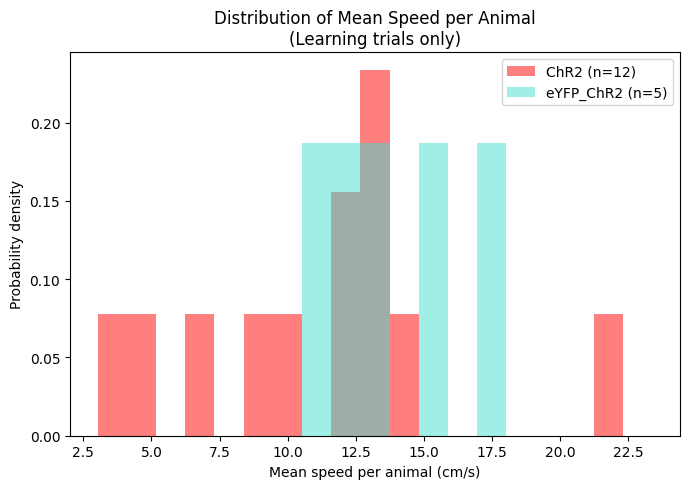

In [21]:
# Distribution of Mean Speed per Animal
# 1) Restrict to LEARNING trials only
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['mean_speed'].notna())
].copy()

# ------------------------------------------------------------
# 2) Per-animal mean speed (average across learning trials)
# ------------------------------------------------------------
meta_animal = (
    meta_L
    .groupby(['genotype', 'sub'])['mean_speed']
    .mean()
    .reset_index()
)

speeds_ChR2 = meta_animal.loc[
    meta_animal['genotype'] == 'ChR2', 'mean_speed'
].values

speeds_eYFP = meta_animal.loc[
    meta_animal['genotype'] == 'eYFP_ChR2', 'mean_speed'
].values

print("Animals included (learning trials only):")
print("  ChR2:", len(speeds_ChR2))
print("  eYFP:", len(speeds_eYFP))

# ------------------------------------------------------------
# 3) Plot histogram
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

bins = np.linspace(
    np.nanmin(meta_animal['mean_speed']),
    np.nanmax(meta_animal['mean_speed']),
    20
)

plt.hist(
    speeds_ChR2,
    bins=bins,
    color='red',
    alpha=0.5,
    density=True,
    label=f'ChR2 (n={len(speeds_ChR2)})'
)

plt.hist(
    speeds_eYFP,
    bins=bins,
    color='turquoise',
    alpha=0.5,
    density=True,
    label=f'eYFP_ChR2 (n={len(speeds_eYFP)})'
)

plt.xlabel('Mean speed per animal (cm/s)')
plt.ylabel('Probability density')
plt.title('Distribution of Mean Speed per Animal\n(Learning trials only)')
plt.legend()
plt.tight_layout()
plt.show()

Speed samples per day:
  Day 1: 456899
  Day 2: 443936
  Day 3: 466650
  Day 4: 437309
  Day 5: 423805
  Day 6: 56880


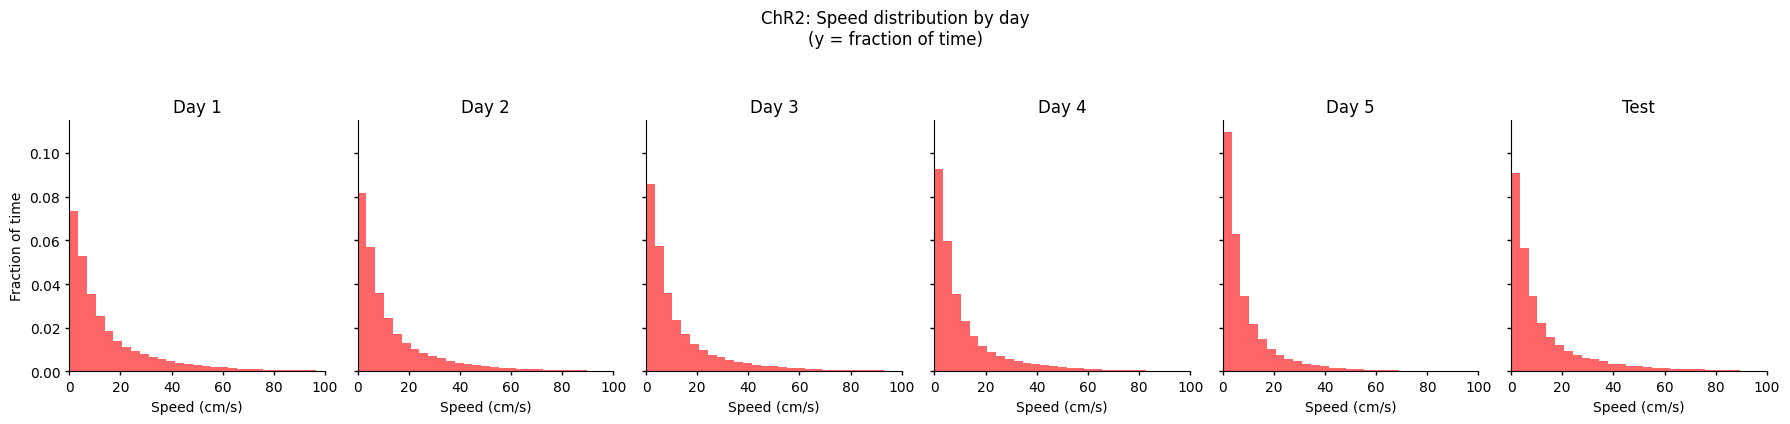

In [ ]:
# =============================================================
# Speed distribution by day (ChR2: L1–L5 + Test)
# =============================================================

days = [1, 2, 3, 4, 5, 6]  # now includes test as day 6

# ------------------------------------------------------------
# 1) Filter usable trials for ChR2 (L + T)
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L','T']))
].copy()

# assign learning trial days 1–5
meta_LT.loc[meta_LT['trial_type']=='L', 'plot_day'] = meta_LT['trial_type_day']

# ------------------------------------------------------------
# 2) Assign FIRST TEST session after learning → plot_day = 6
# ------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub']==sub]

    L_ses = ms.loc[ms['trial_type']=='L', 'ses']
    if len(L_ses)==0:
        continue
    last_L = L_ses.max()

    T_after = ms[(ms['trial_type']=='T') & (ms['ses'] > last_L)]
    if len(T_after)==0:
        continue

    first_T = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub']==sub) &
        (meta_LT['trial_type']=='T') &
        (meta_LT['ses']==first_T)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# keep only days 1–6
meta_LT = meta_LT[meta_LT['plot_day'].isin(days)]

# ------------------------------------------------------------
# 3) Collect SPEED samples per plot_day
# ------------------------------------------------------------
speed_by_day = {d: [] for d in days}

for idx, row in meta_LT.iterrows():
    dl = DataLoader(row)
    pos = dl.get_data('position')
    if pos is None or len(pos)<2:
        continue

    pos = add_speed(pos)
    speeds = pos['speed'].to_numpy()
    speeds = speeds[np.isfinite(speeds)]
    speeds = speeds[speeds>0]

    if len(speeds)==0:
        continue
    
    speed_by_day[int(row['plot_day'])].append(speeds)

# concatenate
for d in days:
    speed_by_day[d] = np.concatenate(speed_by_day[d]) if len(speed_by_day[d])>0 else np.array([])

print("Speed samples per day:")
for d in days:
    print(f"  Day {d}: {len(speed_by_day[d])}")

# ------------------------------------------------------------
# 4) Plot histograms (fraction of time)
# ------------------------------------------------------------

col = get_genotype_color('ChR2')
bins = np.linspace(0, 100, 30)

fig, axes = plt.subplots(1, 6, figsize=(18, 4), sharey=True)

labels = {1:'Day 1', 2:'Day 2', 3:'Day 3', 4:'Day 4', 5:'Day 5', 6:'Test'}

for ax, d in zip(axes, days):
    speeds = speed_by_day[d]
    
    ax.hist(
        speeds,
        bins=bins,
        density=True,
        color=col,
        alpha=0.8,
        edgecolor='none'
    )
    
    ax.set_xlim(0,100)
    ax.set_title(labels[d])
    ax.set_xlabel('Speed (cm/s)')
    if d == 1:
        ax.set_ylabel('Fraction of time')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)

fig.suptitle('ChR2: Speed distribution by day\n(y = fraction of time)',
             y=1.05, fontsize=12)

plt.tight_layout()
plt.show()

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.
The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.
ChR2 animals plotted: 12


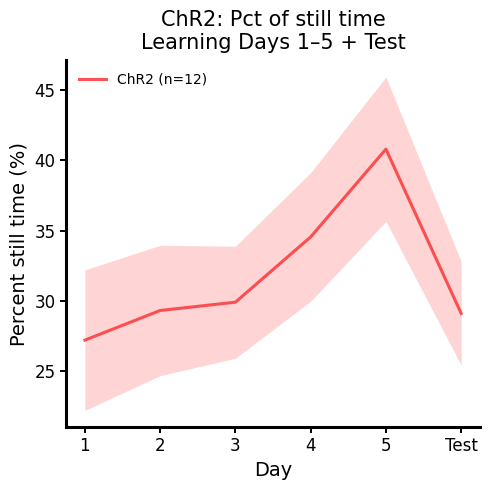

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Compute % still time per trial (using speed threshold)
# ============================================================

STILL_THRESH = 2.0  # cm/s, change if you like

# add column if not present
if 'pct_still' not in metadata.columns:
    metadata['pct_still'] = np.nan

for trial_id in range(len(metadata)):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    pos = add_speed(position)  # must create pos['speed']
    speeds = pos['speed'].to_numpy()
    speeds = speeds[np.isfinite(speeds)]

    if len(speeds) == 0:
        continue

    pct_still = 100.0 * np.mean(speeds < STILL_THRESH)
    metadata.at[trial_id, 'pct_still'] = pct_still

# ============================================================
# 2) Build L1–5 + Test (day 6) for ChR2 only
# ============================================================

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['pct_still'].notna())
].copy()

# init plot_day
meta_LT['plot_day'] = np.nan

# L trials: trial_type_day 1–5
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# assign first T session after last L as day 6
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1–5 + Test
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)]

# ============================================================
# 3) Subject × day matrix: % still time
# ============================================================

def build_matrix_pct_still(meta_g, require_complete=True):
    rows, subs = [], []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_still'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue
        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), subs

mat_ChR2, subs_ChR2 = build_matrix_pct_still(meta_LT, require_complete=True)
print("ChR2 animals plotted:", len(subs_ChR2))

# ============================================================
# 4) Plot mean ± shaded SEM (ChR2 only)
# ============================================================

plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 (for label convenience)

col = get_genotype_color('ChR2')

if mat_ChR2 is not None and len(subs_ChR2) > 0:
    mean_ = np.nanmean(mat_ChR2, axis=0)
    sem_  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])

    # shaded SEM
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=0.22,
        linewidth=0
    )

    # mean line (no markers if you don’t want dots)
    plt.plot(
        x_vals, mean_,
        '-',                # use '-' to avoid dots; '-o' if you want dots
        color=col,
        alpha=0.9,
        linewidth=2.2,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# axes + style
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent still time (%)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('ChR2: Pct of still time\nLearning Days 1–5 + Test', fontsize=15, pad=8)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [23]:
# ------------------------------------------------------------
# Compute mean speed up to FIRST reward-zone arrival
# (optionally require ≥2000 ms stay)
# ------------------------------------------------------------

metadata['mean_speed_to_trigger'] = np.nan

R_TRIGGER = (10 / 1.2)

# ----------------------------
# TOGGLE THIS
# ----------------------------
USE_MIN_DURATION = False      # set False to ignore duration
MIN_DURATION_MS = 2000       # ms
# ----------------------------

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    # add speed + distance info
    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    # collect all trigger visits
    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    # never entered any reward zone
    if len(dfs) == 0:
        metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(pos_['speed'])
        continue

    df_all = (
        pd.concat(dfs, ignore_index=True)
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    # ----------------------------
    # OPTIONAL: require ≥2000 ms stay
    # ----------------------------
    if USE_MIN_DURATION:
        df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

    if len(df_all) == 0:
        # never satisfied criterion → use full trial
        metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(pos_['speed'])
        continue
    # ----------------------------

    # first qualifying entry time
    t_enter_first = df_all.iloc[0]['t_enter']

    # speed up to that time
    idxs = np.where(pos_['t'].values <= t_enter_first)[0]
    if len(idxs) == 0:
        metadata.at[trial_id, 'mean_speed_to_trigger'] = 0.0
        continue

    metadata.at[trial_id, 'mean_speed_to_trigger'] = np.nanmean(
        pos_['speed'].iloc[idxs]
    )

 15%|█▌        | 714/4609 [00:06<00:32, 119.20it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1183/4609 [00:10<00:27, 123.30it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2610/4609 [00:21<00:13, 145.65it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:36<00:00, 126.20it/s]


In [34]:
# ------------------------------------------------------------
# Compute mean speed up to FIRST reward-zone arrival
# ALSO compute mean speed while MOVING (remove still-time samples)
#
# Special rule for trials that never reach ANY reward zone:
#   - Find mean time-to-first-reward for ChR2 animals on THAT plot_day
#   - Use that time window to compute speeds for the non-reach trial
#   - If no ChR2 reaches exist for that day → fallback to full trial
# ------------------------------------------------------------

import numpy as np
import pandas as pd
from tqdm import tqdm

# ----------------------------
# SETTINGS / TOGGLES
# ----------------------------
R_TRIGGER = (10 / 1.2)

USE_MIN_DURATION = False     # set False to ignore duration
MIN_DURATION_MS = 2000       # ms

# define "moving" (remove still time)
MOVING_EPS = 1e-6            # speed > MOVING_EPS counts as moving

# columns to write
COL_MEAN_ALL   = 'mean_speed_to_trigger'
COL_MEAN_MOVE  = 'mean_speed_moving_to_trigger'

metadata[COL_MEAN_ALL]  = np.nan
metadata[COL_MEAN_MOVE] = np.nan

# ------------------------------------------------------------
# 0) Make plot_day for all L/T trials (L1–5, Test=6)
#     (same idea as your other scripts)
# ------------------------------------------------------------
metadata['plot_day'] = np.nan

mask_LT = metadata['trial_type'].isin(['L', 'T'])
mask_L  = (metadata['trial_type'] == 'L') & mask_LT
metadata.loc[mask_L, 'plot_day'] = metadata.loc[mask_L, 'trial_type_day']

for sub in metadata.loc[mask_LT, 'sub'].unique():
    ms = metadata[(metadata['sub'] == sub) & mask_LT]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = metadata.index[
        (metadata['sub'] == sub) &
        (metadata['trial_type'] == 'T') &
        (metadata['ses'] == first_T_ses)
    ]
    metadata.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)

# ------------------------------------------------------------
# 1) PASS 1: For ChR2 only, collect time-to-first-reward per plot_day
# ------------------------------------------------------------
chR2_time_by_day = {d: [] for d in plot_days}

for trial_id in tqdm(range(len(metadata)), desc="Pass 1: ChR2 reach times"):
    row = metadata.iloc[trial_id]
    if row.get('genotype', None) != 'ChR2':
        continue
    d = row.get('plot_day', np.nan)
    if not np.isfinite(d):
        continue
    d = int(d)
    if d not in chR2_time_by_day:
        continue

    dl = DataLoader(row)

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    if len(dfs) == 0:
        continue

    df_all = (
        pd.concat(dfs, ignore_index=True)
        .sort_values('t_enter')
        .reset_index(drop=True)
    )

    if USE_MIN_DURATION:
        df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

    if len(df_all) == 0:
        continue

    t_enter_first = float(df_all.iloc[0]['t_enter'])
    if np.isfinite(t_enter_first):
        chR2_time_by_day[d].append(t_enter_first)

# day-wise mean time-to-first-reward (ChR2)
chR2_mean_t_by_day = {}
print("\nChR2 mean time-to-first-reward per day (for fallback window):")
for d in plot_days:
    arr = np.array(chR2_time_by_day[d], dtype=float)
    m = np.nanmean(arr) if len(arr) else np.nan
    chR2_mean_t_by_day[int(d)] = m
    if np.isfinite(m):
        print(f"  Day {int(d)}: mean t_enter_first = {m:.1f} (n={len(arr)})")
    else:
        print(f"  Day {int(d)}: no ChR2 reaches (n=0)")

# ------------------------------------------------------------
# 2) PASS 2: Compute mean speeds using:
#     - actual t_enter_first if reached
#     - else fallback t_cut = ChR2 mean time for that plot_day
#     - else full trial
# ------------------------------------------------------------
for trial_id in tqdm(range(len(metadata)), desc="Pass 2: compute speeds"):
    row = metadata.iloc[trial_id]

    # only L/T days make sense for plot_day logic; if missing, we still can do full-trial
    plot_day = row.get('plot_day', np.nan)
    plot_day_int = int(plot_day) if np.isfinite(plot_day) else None

    dl = DataLoader(row)

    position = dl.get_data('position')
    if position is None or len(position) < 2:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        continue

    pos = add_speed(position)
    pos_ = add_dist_to_trigger(pos, triggerLoc)

    # collect trigger visits
    dfs = []
    for i in range(len(triggerLoc)):
        df_trig = get_interaction_with_trigger_df(pos_, R_TRIGGER, ti=i + 1)
        if df_trig is None or len(df_trig) == 0:
            continue
        dfs.append(df_trig)

    # decide cutoff time t_cut (same units as pos_['t'] and df_trig['t_enter'])
    t_cut = None

    if len(dfs) > 0:
        df_all = (
            pd.concat(dfs, ignore_index=True)
            .sort_values('t_enter')
            .reset_index(drop=True)
        )
        if USE_MIN_DURATION:
            df_all = df_all[df_all['duration'] >= MIN_DURATION_MS]

        if len(df_all) > 0:
            # reached (under criterion)
            t_cut = float(df_all.iloc[0]['t_enter'])

    # if never reached: fallback to ChR2 mean time for that day
    if (t_cut is None) or (not np.isfinite(t_cut)):
        if plot_day_int is not None:
            t_fallback = chR2_mean_t_by_day.get(plot_day_int, np.nan)
            if np.isfinite(t_fallback):
                t_cut = float(t_fallback)

    # if still no cutoff: use full trial
    if (t_cut is None) or (not np.isfinite(t_cut)):
        t_cut = float(pos_['t'].max())

    # select samples up to cutoff
    idxs = np.where(pos_['t'].values <= t_cut)[0]
    if len(idxs) == 0:
        metadata.at[trial_id, COL_MEAN_ALL]  = 0.0
        metadata.at[trial_id, COL_MEAN_MOVE] = np.nan
        continue

    speeds = pos_['speed'].iloc[idxs].values
    speeds = speeds[np.isfinite(speeds)]

    if len(speeds) == 0:
        metadata.at[trial_id, COL_MEAN_ALL]  = np.nan
        metadata.at[trial_id, COL_MEAN_MOVE] = np.nan
        continue

    # mean speed (includes still time)
    metadata.at[trial_id, COL_MEAN_ALL] = float(np.nanmean(speeds))

    # mean speed while moving (remove still time)
    speeds_move = speeds[speeds > MOVING_EPS]
    metadata.at[trial_id, COL_MEAN_MOVE] = float(np.nanmean(speeds_move)) if len(speeds_move) else np.nan

# quick check
metadata[['sub','ses','trial_type','trial_type_day','plot_day', COL_MEAN_ALL, COL_MEAN_MOVE]].head()

Pass 1: ChR2 reach times: 100%|██████████| 4609/4609 [00:04<00:00, 1019.39it/s]



ChR2 mean time-to-first-reward per day (for fallback window):
  Day 1: mean t_enter_first = 29707.4 (n=95)
  Day 2: mean t_enter_first = 27660.2 (n=93)
  Day 3: mean t_enter_first = 23398.1 (n=95)
  Day 4: mean t_enter_first = 22135.5 (n=96)
  Day 5: mean t_enter_first = 12404.1 (n=96)
  Day 6: mean t_enter_first = 12089.9 (n=12)


Pass 2: compute speeds:  15%|█▌        | 706/4609 [00:06<00:34, 113.40it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


Pass 2: compute speeds:  26%|██▌       | 1179/4609 [00:11<00:29, 118.21it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


Pass 2: compute speeds:  56%|█████▋    | 2603/4609 [00:22<00:11, 175.27it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


Pass 2: compute speeds: 100%|██████████| 4609/4609 [00:37<00:00, 124.43it/s]


,sub,ses,trial_type,trial_type_day,plot_day,mean_speed_to_trigger,mean_speed_moving_to_trigger
0,1,1,H,1,NaN,10.184602,10.271650
1,1,1,H,1,NaN,10.212567,10.331515
2,1,1,H,1,NaN,8.230093,8.504429
3,1,1,H,1,NaN,6.549703,6.775555
4,1,1,H,1,NaN,16.507261,18.249035



=== mean_speed_to_trigger ===
ChR2 animals plotted: 12
eYFP_ChR2 animals plotted: 5
Hp animals plotted: 7


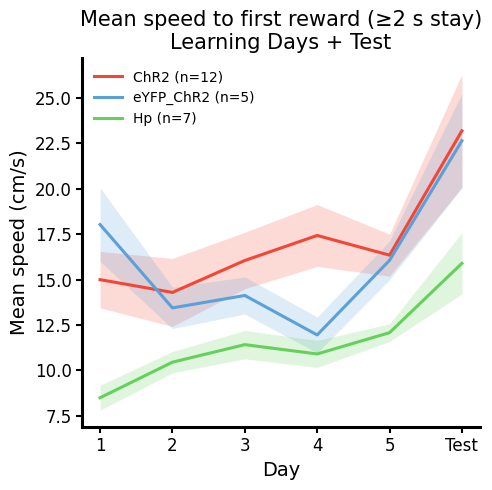

In [ ]:


# ============================================================
# Plot mean speed up to FIRST reward arrival (or fallback window)
# Groups: ChR2 vs eYFP_ChR2, optional + (ChR2_short OR Hp)
# Option: plot moving-only or overall mean speed
# Requires you already computed and stored in metadata:
#   - mean_speed_to_trigger
#   - mean_speed_moving_to_trigger
# ============================================================

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------
PLOT_MOVING_ONLY = False   # False -> mean_speed_to_trigger ; True -> mean_speed_moving_to_trigger
INCLUDE_THIRD    = True   # True -> add third group
USE_SHORT        = False    # True -> third=ChR2_short ; False -> third=Hp
ADD_STAY_TAG     = False   # True -> append "(≥2 s stay)" in titles

# choose which column to plot
SPEED_COL = 'mean_speed_moving_to_trigger' if PLOT_MOVING_ONLY else 'mean_speed_to_trigger'

# ---------------------------------------------------------------------
# 1) Filter metadata: usable, not short, genotypes of interest, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp', 'ChR2_short'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[SPEED_COL].notna())
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix for an arbitrary metric
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (same behaviour as your other scripts)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# ---------------------------------------------------------------------
# 3) Plot helper (keeps same style as your previous distance/CIPL plots)
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col, ylabel, title,
                           include_third=False, use_short=True):
    meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
    meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

    if use_short:
        third_key, third_label = 'ChR2_short', 'ChR2_short'
    else:
        third_key, third_label = 'Hp', 'Hp'
    meta_third = meta_LT[meta_LT['genotype'] == third_key]

    mat_ChR2,  subs_ChR2  = build_genotype_matrix(meta_ChR2,  value_col)
    mat_eYFP,  subs_eYFP  = build_genotype_matrix(meta_eYFP,  value_col)
    mat_third, subs_third = build_genotype_matrix(meta_third, value_col)

    print(f"\n=== {value_col} ===")
    print("ChR2 animals plotted:", len(subs_ChR2))
    print("eYFP_ChR2 animals plotted:", len(subs_eYFP))
    if include_third:
        print(f"{third_key} animals plotted:", len(subs_third))

    plt.figure(figsize=(5, 5))
    x_vals = plot_days - 1

    def plot_group(mat, subs, gkey, glabel):
        if mat is None or mat.size == 0:
            return
        col = get_genotype_color(gkey)

        mean_ = np.nanmean(mat, axis=0)
        sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

        plt.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.20,
            linewidth=0
        )

        plt.plot(
            x_vals, mean_,
            color=col,
            linewidth=2.2,
            label=f'{glabel} (n={len(subs)})'
        )

    plot_group(mat_ChR2, subs_ChR2, 'ChR2', 'ChR2')
    plot_group(mat_eYFP, subs_eYFP, 'eYFP_ChR2', 'eYFP_ChR2')
    if include_third:
        plot_group(mat_third, subs_third, third_key, third_label)

    plt.xlabel('Day', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=15)

    plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)

    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4) Call plot
# ---------------------------------------------------------------------
stay_tag = " (≥2 s stay)" if ADD_STAY_TAG else ""
moving_tag = " (moving only)" if PLOT_MOVING_ONLY else ""

plot_metric_for_groups(
    meta_LT,
    value_col=SPEED_COL,
    ylabel='Mean speed (cm/s)',
    title=f'Mean speed to first reward{moving_tag}{stay_tag}\nLearning Days + Test',
    include_third=INCLUDE_THIRD,
    use_short=USE_SHORT
)


=== mean_speed_to_trigger ===
ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


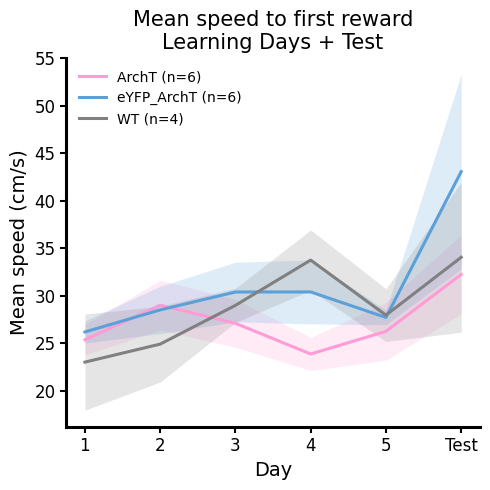

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Plot mean speed up to FIRST reward arrival (or fallback window)
# Groups: ArchT vs eYFP_ArchT, optional + WT
# Option: plot moving-only or overall mean speed
# Requires you already computed and stored in metadata:
#   - mean_speed_to_trigger
#   - mean_speed_moving_to_trigger
# ============================================================

# ---------------------------------------------------------------------
# OPTIONS
# ---------------------------------------------------------------------
PLOT_MOVING_ONLY = False   # False -> mean_speed_to_trigger ; True -> mean_speed_moving_to_trigger
INCLUDE_WT       = True    # True -> add WT, False -> only ArchT & eYFP_ArchT
ADD_STAY_TAG     = False    # True -> append "(≥2 s stay)" in titles

# choose which column to plot
SPEED_COL = 'mean_speed_moving_to_trigger' if PLOT_MOVING_ONLY else 'mean_speed_to_trigger'

# ---------------------------------------------------------------------
# 1) Filter metadata: usable, genotypes of interest, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[SPEED_COL].notna())
].copy()

# Create "plot_day": learning 1–5, test later set = 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b) Assign FIRST T session after last L session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)  # 1..6

# ---------------------------------------------------------------------
# 2) Helper: subject × day matrix for an arbitrary metric
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (same behaviour as your other scripts)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# ---------------------------------------------------------------------
# 3) Plot helper (keeps same style as your previous distance/CIPL plots)
# ---------------------------------------------------------------------
def plot_metric_for_groups(meta_LT, value_col, ylabel, title,
                           include_wt=False):
    meta_ArchT = meta_LT[meta_LT['genotype'] == 'ArchT']
    meta_eYFP  = meta_LT[meta_LT['genotype'] == 'eYFP_ArchT']
    meta_WT    = meta_LT[meta_LT['genotype'] == 'WT']

    mat_ArchT, subs_ArchT = build_genotype_matrix(meta_ArchT, value_col)
    mat_eYFP,  subs_eYFP  = build_genotype_matrix(meta_eYFP,  value_col)
    mat_WT,    subs_WT    = build_genotype_matrix(meta_WT,    value_col)

    print(f"\n=== {value_col} ===")
    print("ArchT animals plotted:", len(subs_ArchT))
    print("eYFP_ArchT animals plotted:", len(subs_eYFP))
    if include_wt:
        print("WT animals plotted:", len(subs_WT))

    plt.figure(figsize=(5, 5))
    x_vals = plot_days - 1

    def plot_group(mat, subs, gkey, glabel):
        if mat is None or mat.size == 0:
            return
        col = get_genotype_color(gkey)

        mean_ = np.nanmean(mat, axis=0)
        sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

        plt.fill_between(
            x_vals,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=0.20,
            linewidth=0
        )

        plt.plot(
            x_vals, mean_,
            color=col,
            linewidth=2.2,
            label=f'{glabel} (n={len(subs)})'
        )

    plot_group(mat_ArchT, subs_ArchT, 'ArchT', 'ArchT')
    plot_group(mat_eYFP,  subs_eYFP,  'eYFP_ArchT', 'eYFP_ArchT')
    if include_wt:
        plot_group(mat_WT, subs_WT, 'WT', 'WT')

    plt.xlabel('Day', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=15)

    plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.5)

    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4) Call plot
# ---------------------------------------------------------------------
stay_tag   = " (≥2 s stay)" if ADD_STAY_TAG else ""
moving_tag = " (moving only)" if PLOT_MOVING_ONLY else ""

plot_metric_for_groups(
    meta_LT,
    value_col=SPEED_COL,
    ylabel='Mean speed (cm/s)',
    title=f'Mean speed to first reward{moving_tag}{stay_tag}\nLearning Days + Test',
    include_wt=INCLUDE_WT
)

Animals plotted:
  ChR2: 10
  eYFP: 5


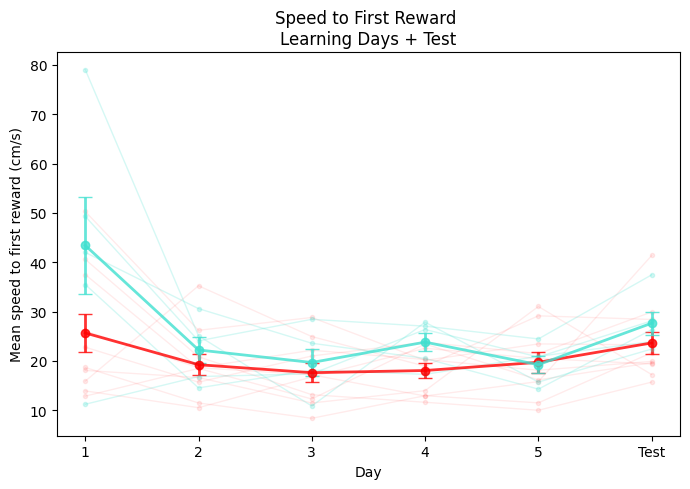

In [100]:
# Speed to first reward zone entry
# Plot ChR2 vs eYFP_ChR2 vs Hp

# ------------------------------------------------------------
# 1) Filter metadata 
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
   # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
        ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['mean_speed_to_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Assign plot_day (L = 1–5, first T after learning = 6)
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan
meta_LT.loc[meta_LT['trial_type'] == 'L', 'plot_day'] = meta_LT['trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)

# ------------------------------------------------------------
# 3) Subject × day matrix
# ------------------------------------------------------------
def build_matrix(meta_g):
    rows, subs = [], []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub]
        mean_by_day = ms.groupby('plot_day')['mean_speed_to_trigger'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue

        rows.append(vals)
        subs.append(sub)

    if len(rows) == 0:
        return None, []

    return np.vstack(rows), subs


#meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
#meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
#meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_matrix(meta_eYFP)
#mat_Hp,   subs_Hp   = build_matrix(meta_Hp)

print("Animals plotted:")
print("  ChR2:", len(subs_ChR2))
print("  eYFP:", len(subs_eYFP))
#print("  Hp  :", len(subs_Hp))

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------

SHOW_INDIVIDUALS = True   # <<< TOGGLE THIS (True / False)

plt.figure(figsize=(7, 5))
x = plot_days - 1

def plot_group(mat, color, label, alpha_mean=0.7, alpha_ind=0.15):
    if mat is None or mat.shape[0] == 0:
        return

    # ----------------------------
    # individual animals (optional)
    # ----------------------------
    if SHOW_INDIVIDUALS:
        for row in mat:
            plt.plot(
                x, row, '-o',
                color=color,
                alpha=alpha_ind,
                linewidth=1,
                markersize=3,
                label='_nolegend_'
            )

    # ----------------------------
    # mean ± SEM
    # ----------------------------
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        alpha=alpha_mean,
        linewidth=2,
        capsize=5,
        label=f'{label} (n={mat.shape[0]})'
    )


plot_group(mat_ChR2, 'red',        'ChR2',       alpha_mean=0.8, alpha_ind=0.08)
plot_group(mat_eYFP, 'turquoise',  'eYFP_ChR2',  alpha_mean=0.8, alpha_ind=0.22)
#plot_group(mat_Hp,   '#2ca02c',    'Hp',         alpha_mean=0.8)

plt.xlabel('Day')
plt.ylabel('Mean speed to first reward (cm/s)')
plt.title('Speed to First Reward \nLearning Days + Test')
#(≥2 s stay)
plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'])
#plt.legend(frameon=False)
plt.tight_layout()
plt.show()
